# UNESCO Tertiary Student Mobility Analysis

## Final Project — Data Analysis Course

### Objective
This project analyzes international student mobility using UNESCO Institute for Statistics data.

We analyze:

- Outbound mobility ratio by country
- Distribution of mobility across countries
- Statistical analysis
- Outlier detection
- Country comparison
- Visualization using multiple plots

---

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

### Dataset Source

UNESCO Institute for Statistics (UIS)

File used:
data.csv

# Load dataset


In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset


In [134]:
df = pd.read_csv("unesco_student_flow.csv")
df.head()

,indicatorId,geoUnit,year,value,qualifier,magnitude
0,MOR.5T8.40510,ABW,2000,10.836500,UIS_EST,NaN
1,MOR.5T8.40510,ABW,2001,9.305900,UIS_EST,NaN
2,MOR.5T8.40510,ABW,2002,20.351761,UIS_EST,NaN
3,MOR.5T8.40510,ABW,2003,8.851670,UIS_EST,NaN
4,MOR.5T8.40510,ABW,2004,14.553990,UIS_EST,NaN


## Dataset Overview

In [135]:
print("Dataset Shape:")
print(df.shape)
print("Columns:")
print(df.columns)
df.info()

Dataset Shape:
(8095, 6)
Columns:
Index(['indicatorId', 'geoUnit', 'year', 'value', 'qualifier', 'magnitude'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8095 entries, 0 to 8094
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   indicatorId  8095 non-null   str    
 1   geoUnit      8095 non-null   str    
 2   year         8095 non-null   int64  
 3   value        8095 non-null   float64
 4   qualifier    3891 non-null   str    
 5   magnitude    0 non-null      float64
dtypes: float64(2), int64(1), str(3)
memory usage: 379.6 KB


## Statistical Summary

In [136]:
df.describe()

,year,value,magnitude
count,8095.000000,8095.000000,0.0
mean,2011.302162,11.901898,NaN
std,6.794459,152.924897,NaN
min,2000.000000,0.179690,NaN
25%,2005.000000,1.891885,NaN
50%,2011.000000,3.457480,NaN
75%,2017.000000,6.239775,NaN
max,2023.000000,12550.000000,NaN


## Check Missing Values

In [137]:
df.isnull().sum()

indicatorId       0
geoUnit           0
year              0
value             0
qualifier      4204
magnitude      8095
dtype: int64

## Check duplicate rows

In [138]:
df.duplicated().sum()

np.int64(0)

## Initial Observations

In [139]:
df.head()

,indicatorId,geoUnit,year,value,qualifier,magnitude
0,MOR.5T8.40510,ABW,2000,10.836500,UIS_EST,NaN
1,MOR.5T8.40510,ABW,2001,9.305900,UIS_EST,NaN
2,MOR.5T8.40510,ABW,2002,20.351761,UIS_EST,NaN
3,MOR.5T8.40510,ABW,2003,8.851670,UIS_EST,NaN
4,MOR.5T8.40510,ABW,2004,14.553990,UIS_EST,NaN


# Data Cleaning and Preparation


In [140]:
# We will focus on these columns:
key_cols = ["indicatorId", "geoUnit", "year", "value", "qualifier"]
df[key_cols].head()
df[key_cols].dtypes

indicatorId        str
geoUnit            str
year             int64
value          float64
qualifier          str
dtype: object

# Check Missing Values

In [141]:
df[key_cols].isnull().sum()

indicatorId       0
geoUnit           0
year              0
value             0
qualifier      4204
dtype: int64

In [142]:
df_clean = df.drop(columns=["magnitude"])

# Filter specific indicator

In [143]:
df_clean = df_clean[df_clean["indicatorId"] == "MOR.5T8.40510"]  
df_clean.reset_index(drop=True, inplace=True)
df_clean.head()

,indicatorId,geoUnit,year,value,qualifier
0,MOR.5T8.40510,ABW,2000,10.836500,UIS_EST
1,MOR.5T8.40510,ABW,2001,9.305900,UIS_EST
2,MOR.5T8.40510,ABW,2002,20.351761,UIS_EST
3,MOR.5T8.40510,ABW,2003,8.851670,UIS_EST
4,MOR.5T8.40510,ABW,2004,14.553990,UIS_EST


# Handle missing values

In [144]:
df_clean["qualifier"].fillna("None", inplace=True)

/var/folders/9t/lw84bl150216vm671xpk_6zm0000gn/T/ipykernel_15933/730312872.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean["qualifier"].fillna("None", inplace=True)


0       UIS_EST
1       UIS_EST
2       UIS_EST
3       UIS_EST
4       UIS_EST
         ...   
8090    UIS_EST
8091    UIS_EST
8092    UIS_EST
8093    UIS_EST
8094       None
Name: qualifier, Length: 8095, dtype: str

# Filter years (optional)

In [145]:
df_clean = df_clean[(df_clean["year"] >= 2015) & (df_clean["year"] <= 2021)]
df_clean.reset_index(drop=True, inplace=True)
df_clean.head()

,indicatorId,geoUnit,year,value,qualifier
0,MOR.5T8.40510,ABW,2015,19.130289,UIS_EST
1,MOR.5T8.40510,ABW,2016,20.121960,NaN
2,MOR.5T8.40510,AFG,2018,8.236080,NaN
3,MOR.5T8.40510,AFG,2020,7.690300,NaN
4,MOR.5T8.40510,AGO,2015,6.158580,NaN


# Check duplicates

In [146]:
df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)

# Outlier detection (initial check)

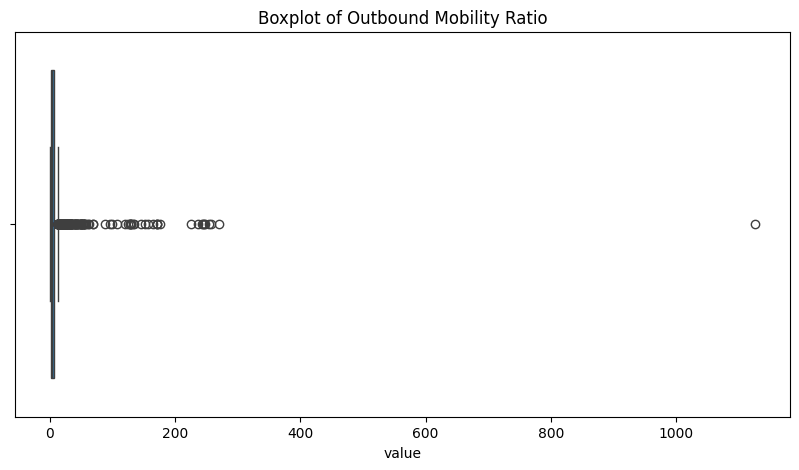

In [147]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean["value"])
plt.title("Boxplot of Outbound Mobility Ratio")
plt.show()

In [148]:
print("Cleaned Dataset Shape:", df_clean.shape)
df_clean.describe()

Cleaned Dataset Shape: (2335, 5)


,year,value
count,2335.000000,2335.000000
mean,2017.913490,8.492574
std,1.997484,31.150794
min,2015.000000,0.242510
25%,2016.000000,2.132540
50%,2018.000000,3.747940
75%,2020.000000,6.202080
max,2021.000000,1125.691772


# Exploratory Data Analysis (EDA) & Visualization

In [149]:
print("Available years:", df_clean["year"].unique())
print("Number of countries:", df_clean["geoUnit"].nunique())
print("Top 5 countries:\n", df_clean["geoUnit"].value_counts().head())

Available years: [2015 2016 2018 2020 2017 2019 2021]
Number of countries: 377
Top 5 countries:
 geoUnit
AIMS: Asia and the Pacific         7
AIMS: Central Asia                 7
AIMS: East Asia                    7
AIMS: East Asia and the Pacific    7
AIMS: Pacific                      7
Name: count, dtype: int64


# Distribution of Outbound Mobility Ratio

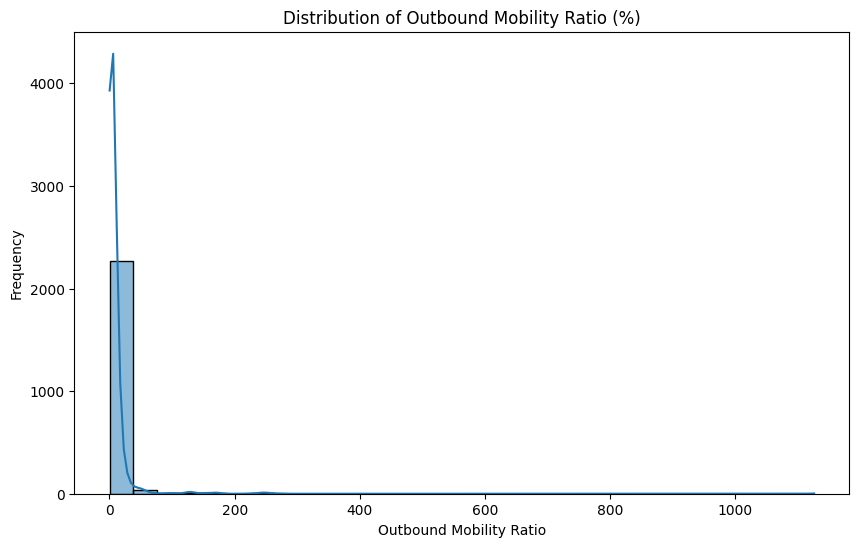

In [150]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean["value"], bins=30, kde=True)
plt.title("Distribution of Outbound Mobility Ratio (%)")
plt.xlabel("Outbound Mobility Ratio")
plt.ylabel("Frequency")
plt.show()

## Boxplot by year

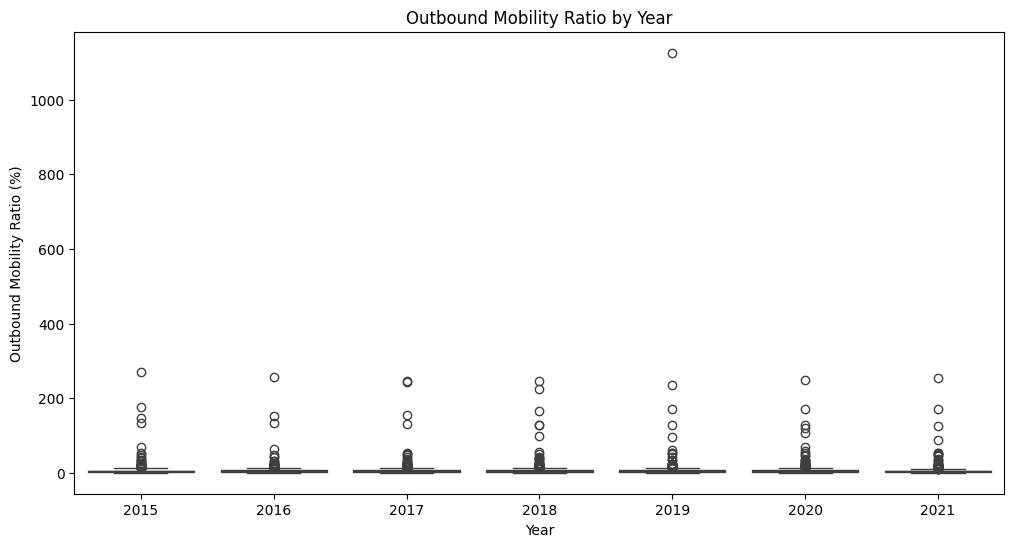

In [151]:
plt.figure(figsize=(12,6))
sns.boxplot(x="year", y="value", data=df_clean)
plt.title("Outbound Mobility Ratio by Year")
plt.xlabel("Year")
plt.ylabel("Outbound Mobility Ratio (%)")
plt.show()

# Top 10 countries (highest outbound mobility)

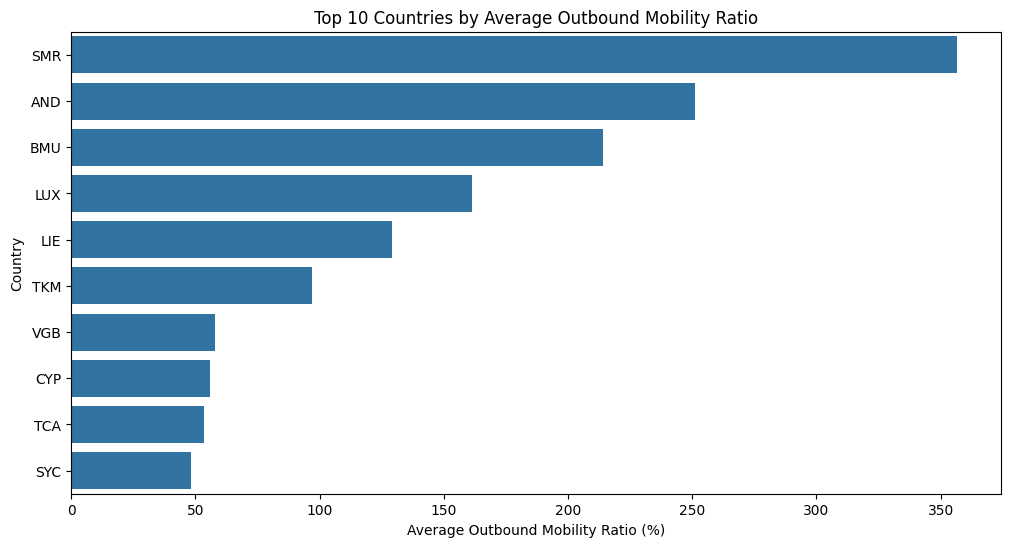

In [152]:
top10_countries = df_clean.groupby("geoUnit")["value"].mean().sort_values(ascending=False).head(10)
top10_countries

plt.figure(figsize=(12,6))
sns.barplot(x=top10_countries.values, y=top10_countries.index)
plt.title("Top 10 Countries by Average Outbound Mobility Ratio")
plt.xlabel("Average Outbound Mobility Ratio (%)")
plt.ylabel("Country")
plt.show()

# Bottom 10 countries (lowest outbound mobility)

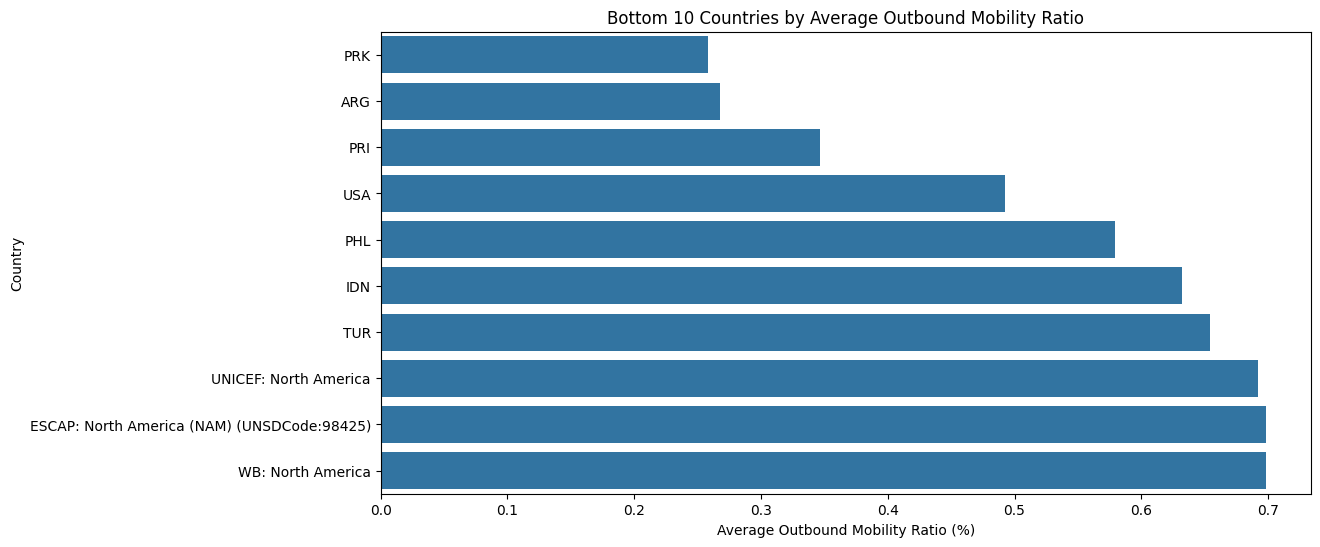

In [153]:
bottom10_countries = df_clean.groupby("geoUnit")["value"].mean().sort_values().head(10)
bottom10_countries

plt.figure(figsize=(12,6))
sns.barplot(x=bottom10_countries.values, y=bottom10_countries.index)
plt.title("Bottom 10 Countries by Average Outbound Mobility Ratio")
plt.xlabel("Average Outbound Mobility Ratio (%)")
plt.ylabel("Country")
plt.show()

# Yearly trend for top countries

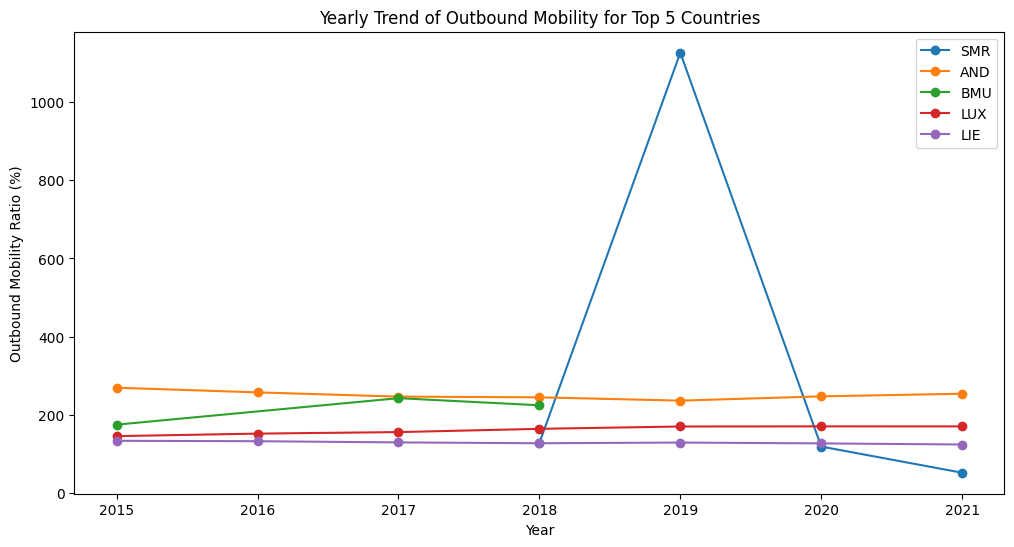

In [154]:
top5_countries = df_clean.groupby("geoUnit")["value"].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(12,6))
for country in top5_countries:
    country_data = df_clean[df_clean["geoUnit"] == country]
    plt.plot(country_data["year"], country_data["value"], marker='o', label=country)

plt.title("Yearly Trend of Outbound Mobility for Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("Outbound Mobility Ratio (%)")
plt.legend()
plt.show()

# Pivot Table: average mobility by year

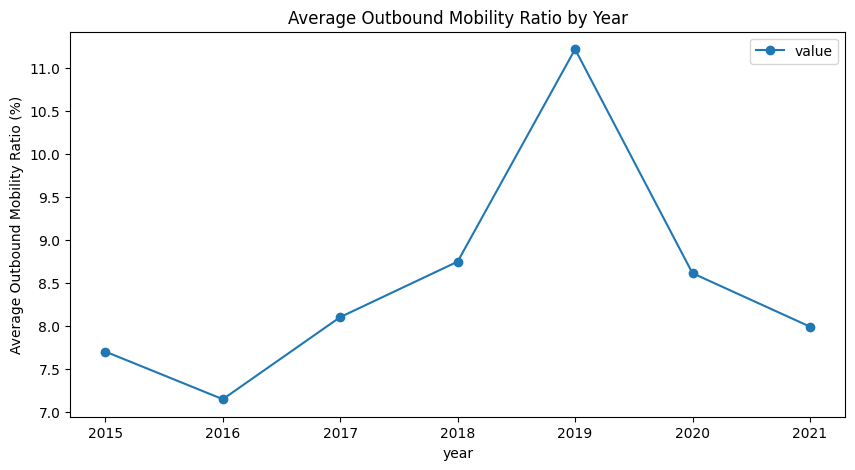

In [155]:
pivot_year = df_clean.pivot_table(index="year", values="value", aggfunc="mean")
pivot_year
pivot_year.plot(kind="line", figsize=(10,5), marker='o', title="Average Outbound Mobility Ratio by Year")
plt.ylabel("Average Outbound Mobility Ratio (%)")
plt.show()

# Outlier detection (Z-score method)

In [156]:
from scipy.stats import zscore

df_clean["z_score"] = zscore(df_clean["value"])
outliers = df_clean[df_clean["z_score"].abs() > 3]
print("Number of outliers:", outliers.shape[0])
outliers[["geoUnit","year","value","z_score"]].head()

Number of outliers: 28


,geoUnit,year,value,z_score
85,AND,2015,269.601013,8.383875
86,AND,2016,257.649323,8.000121
87,AND,2017,246.826370,7.652609
88,AND,2018,245.047226,7.595483
89,AND,2019,236.594498,7.324076


# Histogram after removing outliers

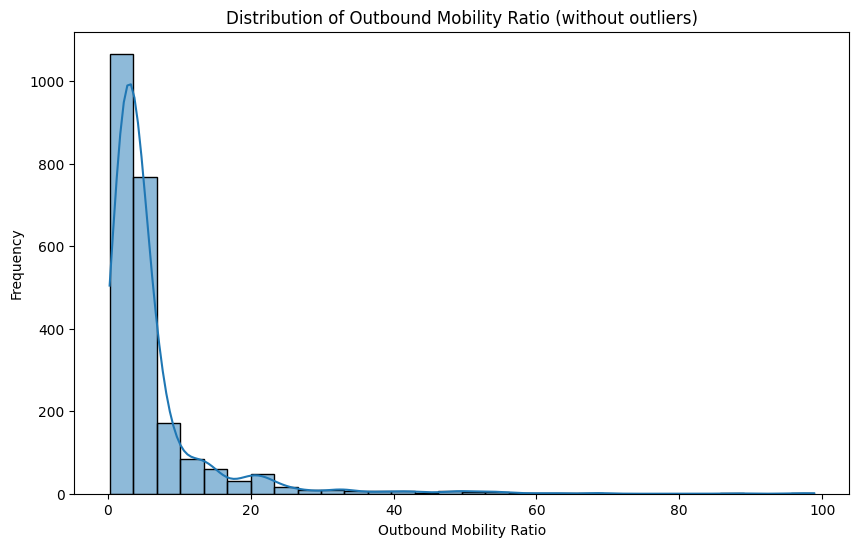

In [157]:
df_no_outliers = df_clean[df_clean["z_score"].abs() <= 3]

plt.figure(figsize=(10,6))
sns.histplot(df_no_outliers["value"], bins=30, kde=True)
plt.title("Distribution of Outbound Mobility Ratio (without outliers)")
plt.xlabel("Outbound Mobility Ratio")
plt.ylabel("Frequency")
plt.show()

# Summary statistics after EDA

In [158]:
df_no_outliers["value"].describe()

count    2307.000000
mean        6.031104
std         8.265083
min         0.242510
25%         2.119145
50%         3.721480
75%         5.991010
max        98.883789
Name: value, dtype: float64

# Total students per year

year
2015    2758.740620
2016    2474.739455
2017    2715.802073
2018    2931.751296
2019    3702.547852
2020    2791.785828
2021    2454.793146
Name: value, dtype: float64


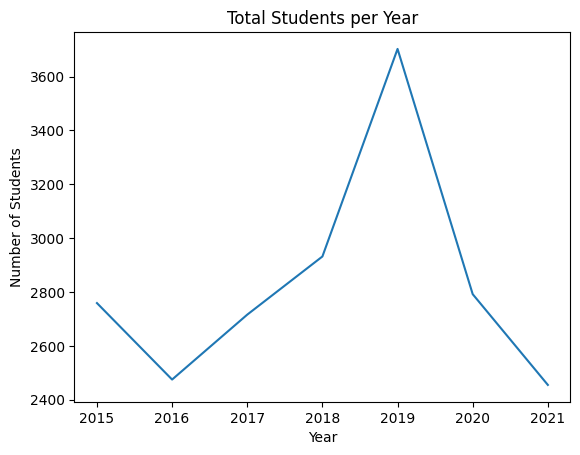

In [159]:
students_per_year = df_clean.groupby('year')['value'].sum()

print(students_per_year)
plt.figure()
students_per_year.plot()
plt.title("Total Students per Year")
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.show()

# Top countries by student value

geoUnit
AND    1757.430908
SMR    1425.760052
LUX    1130.868454
LIE     905.487419
BMU     642.790649
CYP     392.789726
VGB     346.737770
SYC     338.996765
TKM     290.575302
MCO     288.863548
Name: value, dtype: float64


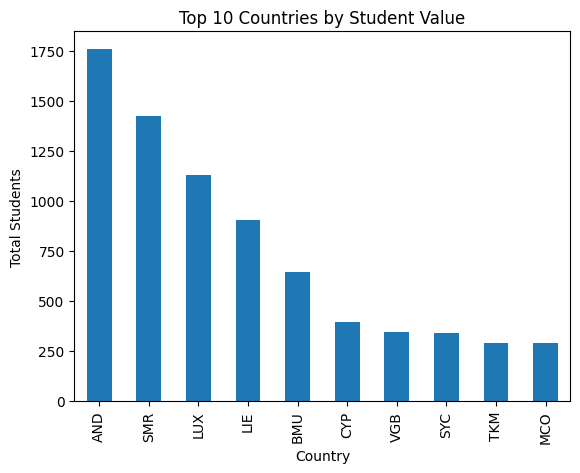

In [160]:
top_countries = df_clean.groupby('geoUnit')['value'].sum()
top_countries = top_countries.sort_values(ascending=False)
top10 = top_countries.head(10)
print(top10)

plt.figure()
top10.plot(kind='bar')
plt.title("Top 10 Countries by Student Value")
plt.xlabel("Country")
plt.ylabel("Total Students")
plt.show()

# Year with maximum students

In [161]:
max_year = students_per_year.idxmax()
max_value = students_per_year.max()

print("Year with maximum students:", max_year)
print("Maximum value:", max_value)

Year with maximum students: 2019
Maximum value: 3702.547852158547


# Statistics

In [162]:
print("Mean:", df_clean['value'].mean())
print("Median:", df_clean['value'].median())
print("Max:", df_clean['value'].max())
print("Min:", df_clean['value'].min())

Mean: 8.492573991539135
Median: 3.747940063476563
Max: 1125.691772460938
Min: 0.2425100058317184


# Boxplot by year

<Figure size 640x480 with 0 Axes>

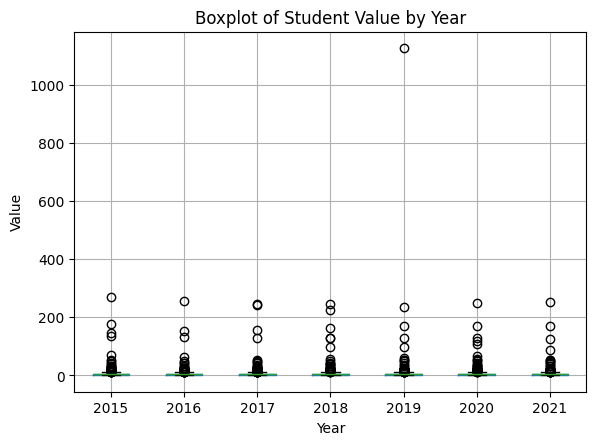

In [163]:
plt.figure()
df_clean.boxplot(column='value', by='year')
plt.title("Boxplot of Student Value by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()

# Identify fastest growing country

In [164]:
growth = {}
countries = df_clean['geoUnit'].unique()
for country in countries:
    data = df_clean[df_clean['geoUnit'] == country]
    yearly = data.groupby('year')['value'].sum()
    if len(yearly) >= 2: 
        growth_value = yearly.iloc[-1] - yearly.iloc[0]   
        growth[country] = growth_value

growth_series = pd.Series(growth)
growth_series = growth_series.sort_values(ascending=False)

print("Top growing countries:")
print(growth_series.head(10))

Top growing countries:
BMU    49.505249
LUX    24.891708
SYC    14.733971
TCD    14.266620
UZB    10.585001
NPL     9.960239
BIH     7.987690
LAO     7.323090
CPV     7.087931
MDA     6.988129
dtype: float64


# Histogram

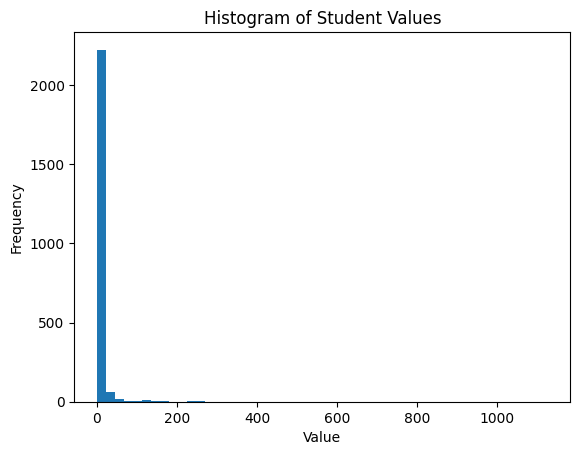

In [165]:
plt.figure()
plt.hist(df_clean['value'], bins=50)
plt.title("Histogram of Student Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

# Scatter plot (Year vs Value)

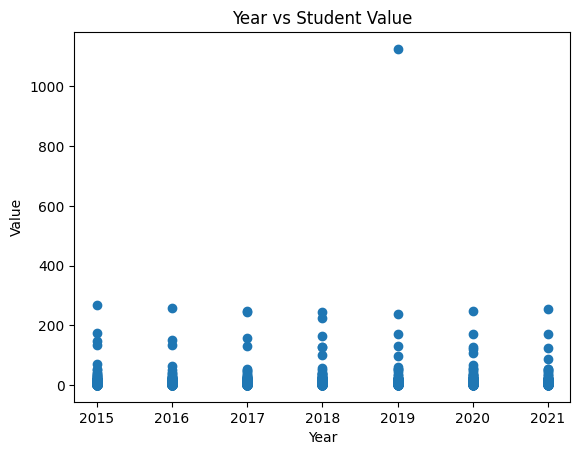

In [166]:
plt.figure()
plt.scatter(df_clean['year'], df_clean['value'])
plt.title("Year vs Student Value")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()

# Pivot table

In [167]:
pivot_table = df_clean.pivot_table(
    values='value',
    index='geoUnit',
    columns='year',
    aggfunc='mean'
)
pivot_table.head()

year,2015,2016,2017,2018,2019,2020,2021
geoUnit,,,,,,,
ABW,19.130289,20.12196,NaN,NaN,NaN,NaN,NaN
AFG,NaN,NaN,NaN,8.23608,NaN,7.690300,NaN
AGO,6.158580,6.15461,NaN,NaN,NaN,NaN,NaN
AIMS: Asia and the Pacific,1.721720,1.84947,1.94580,2.07227,2.17461,2.249550,2.065190
AIMS: Central Asia,12.480480,14.08601,13.45954,14.68230,15.32455,16.581261,16.418011


# Heatmap

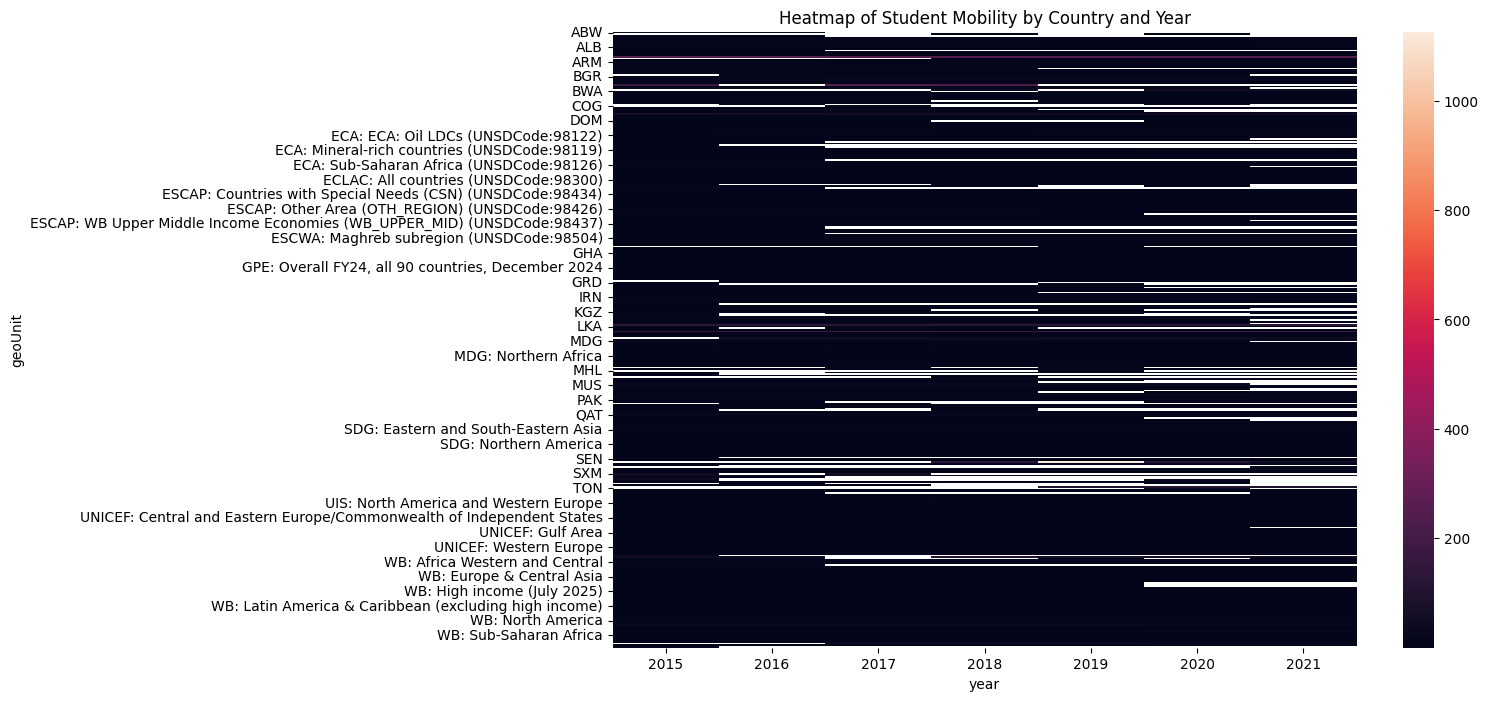

In [168]:
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table)
plt.title("Heatmap of Student Mobility by Country and Year")
plt.show()

In [169]:
pivot_filled = pivot_table.fillna(0)
pivot_filled.head()

year,2015,2016,2017,2018,2019,2020,2021
geoUnit,,,,,,,
ABW,19.130289,20.12196,0.00000,0.00000,0.00000,0.000000,0.000000
AFG,0.000000,0.00000,0.00000,8.23608,0.00000,7.690300,0.000000
AGO,6.158580,6.15461,0.00000,0.00000,0.00000,0.000000,0.000000
AIMS: Asia and the Pacific,1.721720,1.84947,1.94580,2.07227,2.17461,2.249550,2.065190
AIMS: Central Asia,12.480480,14.08601,13.45954,14.68230,15.32455,16.581261,16.418011


# Find country with highest value per year

In [170]:
max_per_year = pivot_filled.idxmax()

print("Country with highest mobility each year:")
print(max_per_year)

Country with highest mobility each year:
year
2015    AND
2016    AND
2017    AND
2018    AND
2019    SMR
2020    AND
2021    AND
dtype: str


# Correlation Analysis

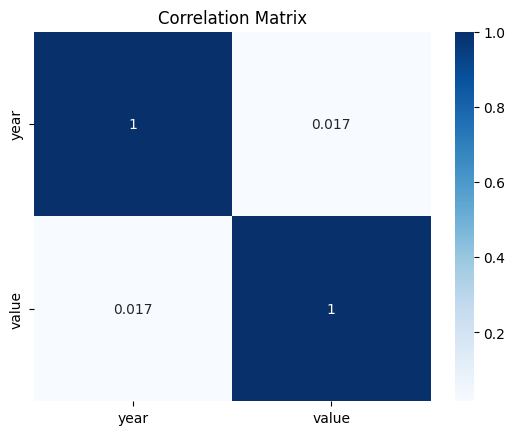

In [171]:
correlation_matrix = df_clean[['year', 'value']].corr()

plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

# Advanced Correlation Analysis

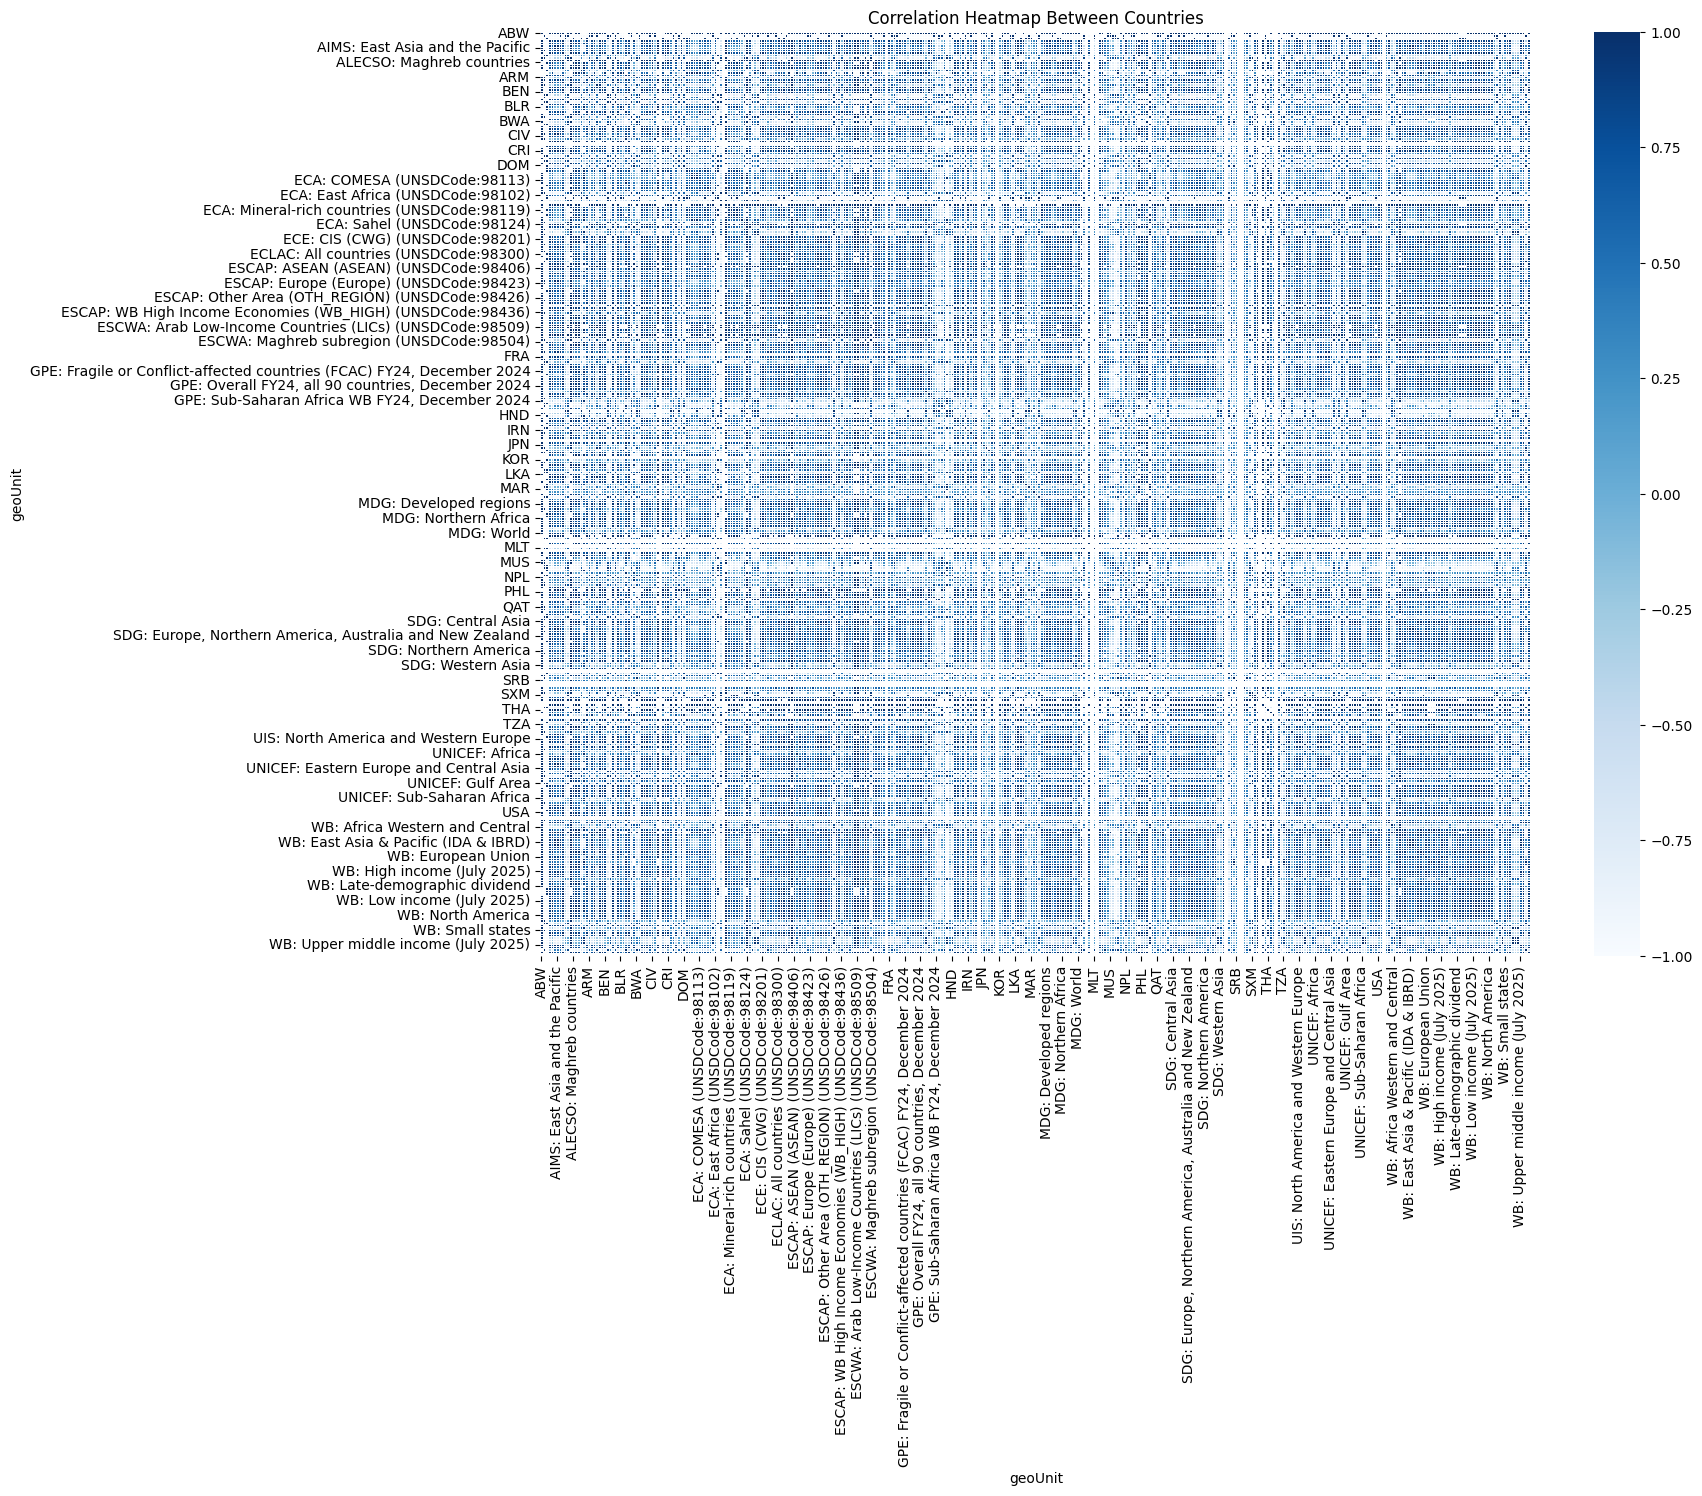

In [172]:
pivot_corr = df_clean.pivot_table(
    index="year",
    columns="geoUnit",
    values="value"
)
pivot_corr.head()

correlation_matrix = pivot_corr.corr()
correlation_matrix.head()

plt.figure(figsize=(16,12))
sns.heatmap(
    correlation_matrix,
    cmap="Blues",
    linewidths=0.5
)
plt.title("Correlation Heatmap Between Countries")
plt.show()

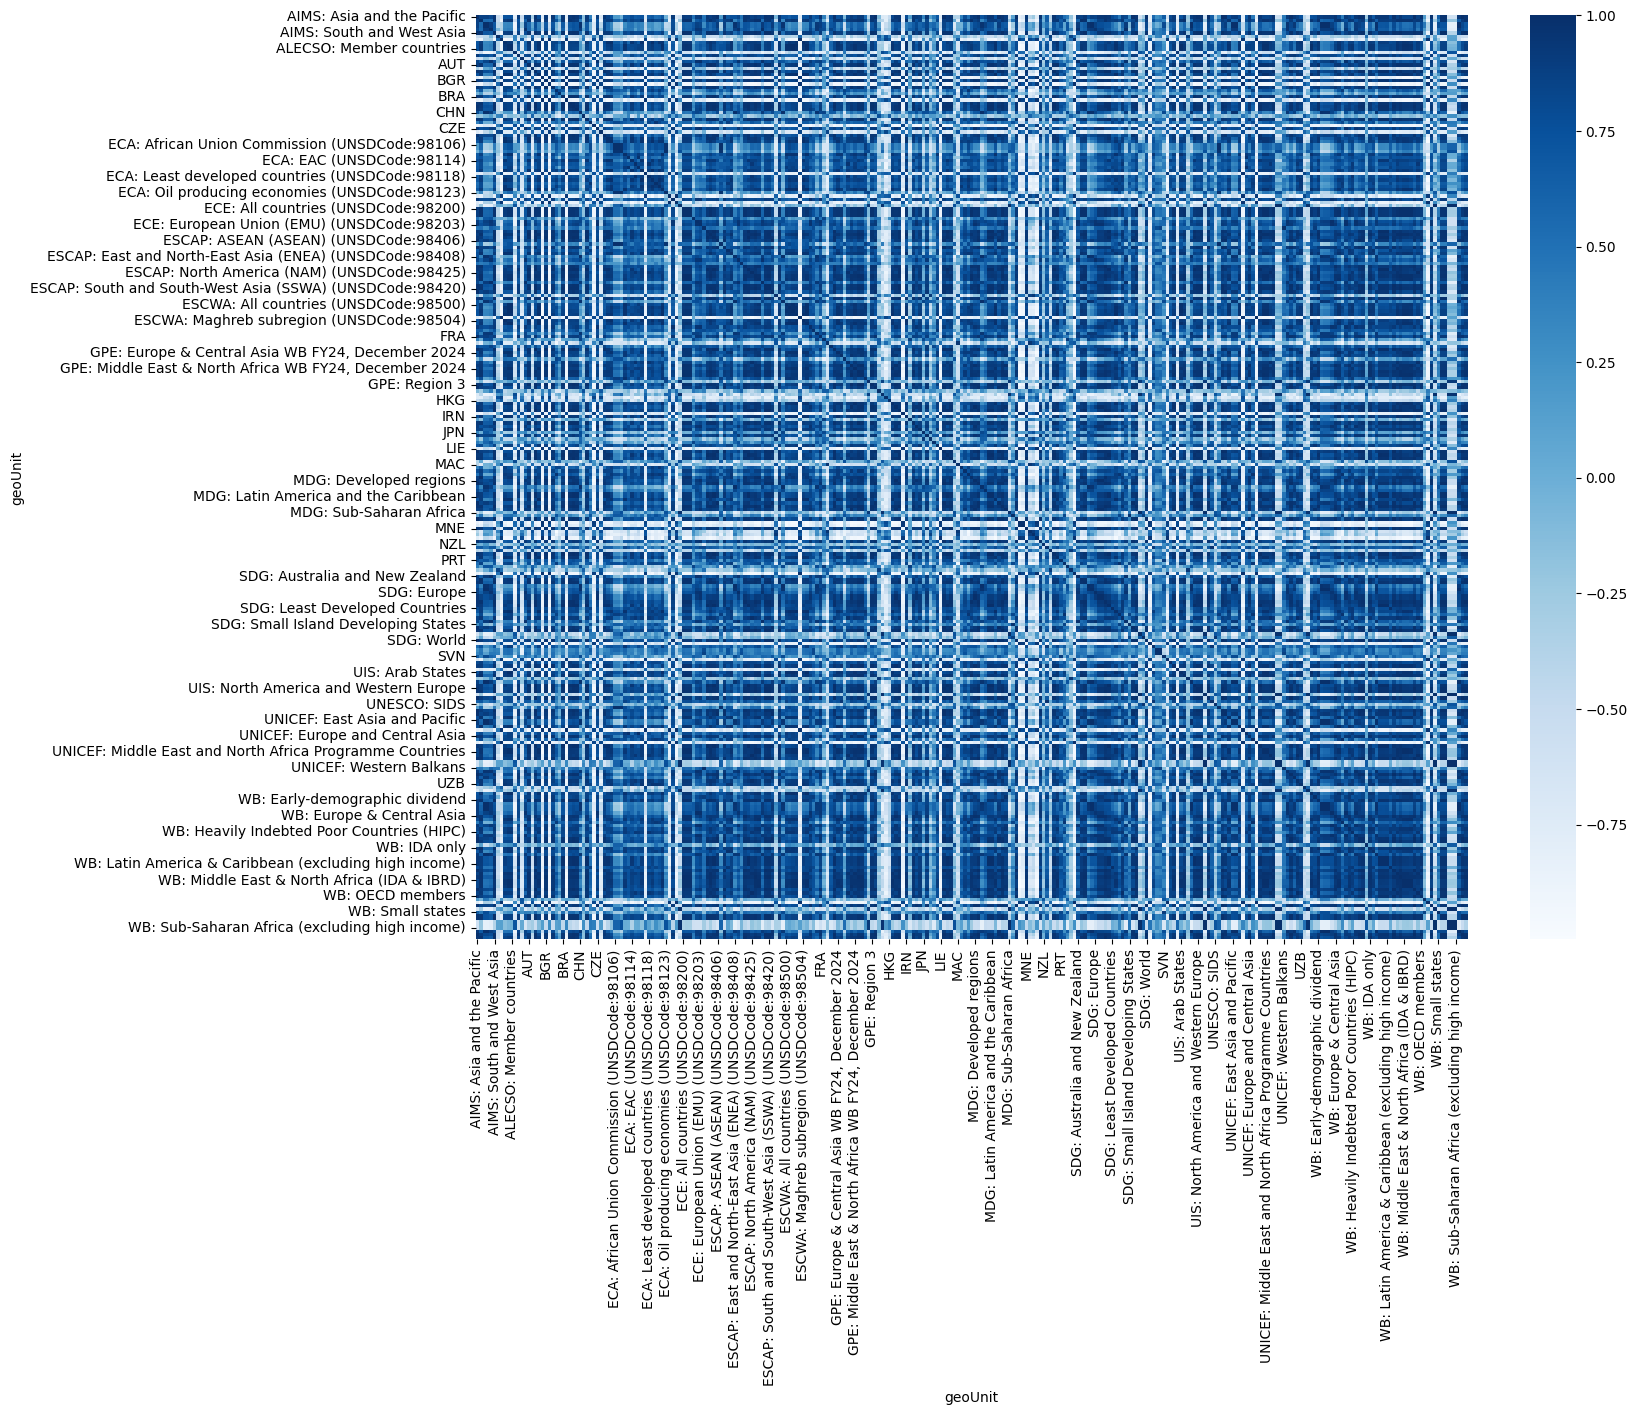

In [173]:
num = pivot_corr.dropna(axis=1)

plt.figure(figsize=(16,12))
sns.heatmap(
    num.corr(),
    annot=False,
    fmt=".3f",
    cmap="Blues"
)
plt.show()

# Covariance Analysis

In [174]:
covariance_matrix = df_clean[['year', 'value']].cov()

covariance_matrix

,year,value
year,3.989942,1.038773
value,1.038773,970.371946


# Advanced Outlier Detection (IQR Method)

In [175]:
Q1 = df_clean['value'].quantile(0.25)
Q3 = df_clean['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
outliers = df_clean[
    (df_clean['value'] < lower_bound) |
    (df_clean['value'] > upper_bound)
]
print("Number of outliers:", len(outliers))

outliers.head()

Lower bound: -3.97177004814148
Upper bound: 12.306390047073364
Number of outliers: 282


,indicatorId,geoUnit,year,value,qualifier,z_score
0,MOR.5T8.40510,ABW,2015,19.130289,UIS_EST,0.341564
1,MOR.5T8.40510,ABW,2016,20.121960,NaN,0.373405
13,MOR.5T8.40510,AIMS: Central Asia,2015,12.480480,NaN,0.128047
14,MOR.5T8.40510,AIMS: Central Asia,2016,14.086010,NaN,0.179598
15,MOR.5T8.40510,AIMS: Central Asia,2017,13.459540,NaN,0.159483


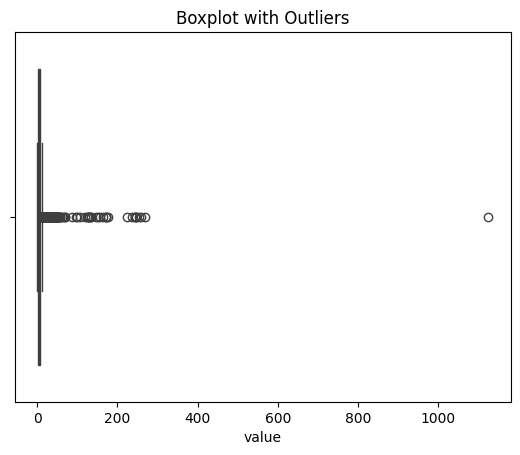

In [176]:
plt.figure()
sns.boxplot(x=df_clean['value'])
plt.title("Boxplot with Outliers")
plt.show()

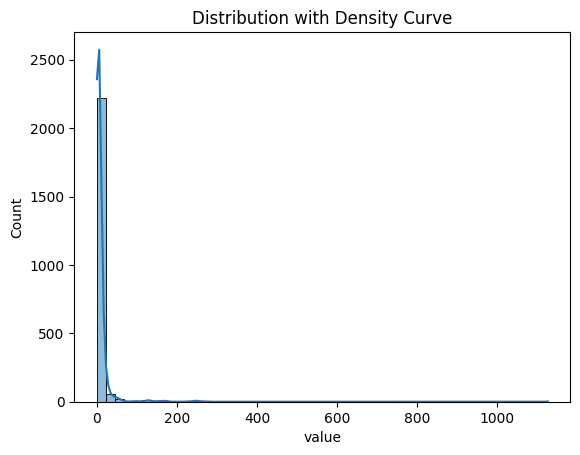

In [177]:
plt.figure()
sns.histplot(df_clean['value'], bins=50, kde=True)
plt.title("Distribution with Density Curve")
plt.show()

# Key Statistics

In [178]:
print("Minimum value:", df_clean['value'].min())
print("Maximum value:", df_clean['value'].max())
print("Mean value:", df_clean['value'].mean())
print("Median value:", df_clean['value'].median())
print("Standard deviation:", df_clean['value'].std())

Minimum value: 0.2425100058317184
Maximum value: 1125.691772460938
Mean value: 8.492573991539135
Median value: 3.747940063476563
Standard deviation: 31.150793666557345


# Export Clean Dataset

In [179]:
df_clean.to_csv("cleaned_unesco_student_mobility.csv", index=False)

print("Dataset exported successfully.")

Dataset exported successfully.


# Final Visualization

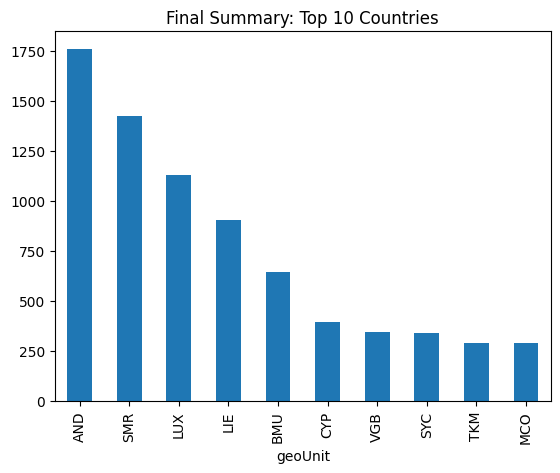

In [180]:
plt.figure()
top10 = (
    df_clean.groupby('geoUnit')['value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top10.plot(kind='bar')
plt.title("Final Summary: Top 10 Countries")
plt.show()